In [ ]:
import yfinance as yf
import cira 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from os.path import exists

cira.auth.KEY_FILE = ""
assert not cira.auth.check_keys(), "the set keys dose not work"

SYMBOL = "ETH/USD" 
SYM_HIST_FILE = f'./{SYMBOL.replace("/", "_")}.csv'

ast = cira.Cryptocurrency(SYMBOL)

if not exists(SYM_HIST_FILE): # chacheing historical data  
    start = datetime(2020, 1, 1)
    end = datetime.now().date() 
    ast.save_historical_data(SYM_HIST_FILE, start, end)

data = ast.load_historical_data(SYM_HIST_FILE)
data.head()

,symbol,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,,
2021-01-01 06:00:00+00:00,ETH/USD,742.15,745.00,716.65,733.65,6534.81013,6514.0,731.807780
2021-01-02 06:00:00+00:00,ETH/USD,735.29,791.08,725.44,786.88,16071.74933,15214.0,769.787732
2021-01-03 06:00:00+00:00,ETH/USD,786.64,1098.00,784.55,1086.86,44039.92386,43031.0,942.620484
2021-01-04 06:00:00+00:00,ETH/USD,1086.86,1169.05,880.00,991.40,50778.44556,51353.0,1030.893782
2021-01-05 06:00:00+00:00,ETH/USD,992.00,1138.00,980.08,1105.56,25283.79028,26369.0,1073.661942


<Axes: xlabel='timestamp'>

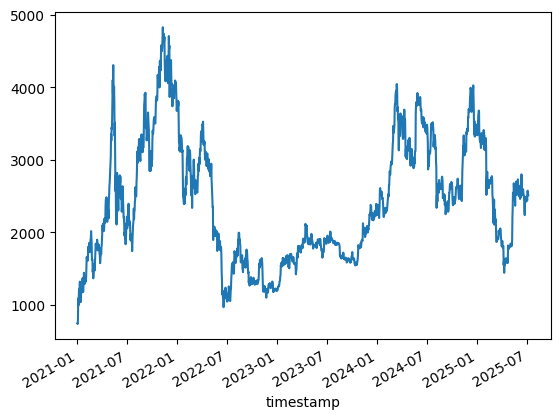

In [ ]:
data["open"].plot()

In [10]:
date = datetime.now().date().strftime('%Y-%m-%d')
date

'2025-07-07'

In [13]:
ticker = yf.Ticker('AAPL')
all_dates = ticker.quarterly_income_stmt.columns
all_dates

DatetimeIndex(['2025-03-31', '2024-12-31', '2024-09-30', '2024-06-30',
               '2024-03-31'],
              dtype='datetime64[ns]', freq=None)

In [15]:
total_shares = ticker.quarterly_income_stmt["2025-03-31"]['Basic Average Shares']
total_shares

np.float64(14994082000.0)

<Axes: xlabel='Date'>

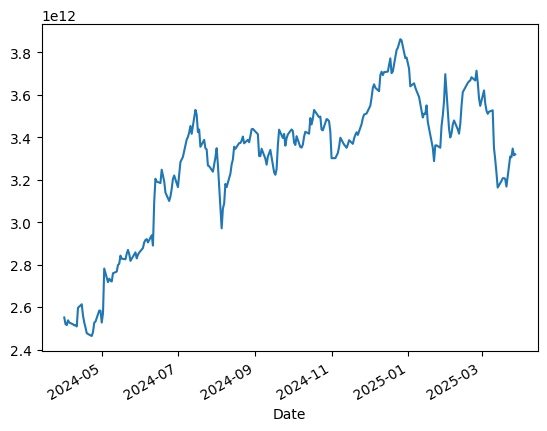

In [21]:
stock_price = ticker.history(start='2024-03-31', end='2025-03-31')["Open"]
market_cap = stock_price * total_shares
market_cap.plot()

In [22]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'5000',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': 'b54bcf4d-1bca-4e8e-9a24-22ff2c3d462c',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

{'status': {'timestamp': '2025-07-07T12:48:45.620Z', 'error_code': 0, 'error_message': None, 'elapsed': 2, 'credit_count': 1, 'notice': None}, 'data': [{'id': 3605, 'name': 'ls8z5g4xct', 'symbol': '8isgn1hr6fq', 'slug': '9j4mqnik9m4', 'cmc_rank': 6006, 'num_market_pairs': 3144, 'circulating_supply': 3404, 'total_supply': 830, 'max_supply': 2646, 'infinite_supply': None, 'last_updated': '2025-07-07T12:48:45.620Z', 'date_added': '2025-07-07T12:48:45.620Z', 'tags': ['bpr1afr1j2d', 'g0xw09ja72o', '99cncheyvea', 'q92cjbtdh5n', 'psxg8rk6qh', 'xixosl28j9', '3rav0zb4joy', 'vo7bhg4fwpj', 'p2ferfzo0c', 'zevkutcq3fa'], 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'quote': {'USD': {'price': 0.48719110580455083, 'volume_24h': 5584, 'volume_change_24h': 0.2774587521751646, 'percent_change_1h': 0.9974823252595966, 'percent_change_24h': 0.06107160076264839, 'percent_change_7d': 0.013489121362216805, 'market_cap': 0.20234969216710819, 'market_cap_dominan